# NexusTrader Experiments — Clean Notebook (v3 / v4 / v5)

This notebook is a clean, reproducible workflow for:
1. Loading **saved raw agent runs** from JSONL
2. Recomputing **baselines** on the same universe
3. Scoring everything with k-day forward returns
4. Producing unified comparison tables/charts

No duplicated sections, no legacy clutter.

In [68]:
from __future__ import annotations

import json
import random
from dataclasses import dataclass
from datetime import datetime, timedelta
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
pd.set_option("display.max_columns", 200)

## 1) Paths and Experiment Configuration

In [72]:
ROOT = Path(r"c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments")
RAW_DIR = ROOT / "results" / "raw"
SCORED_DIR = ROOT / "results" / "scored"
CHART_DIR = ROOT / "results" / "charts"

SCORED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MAP = {"short": 10, "medium": 21, "long": 126}
HOLD_EPSILON = 0.025
RANDOM_SEED = 42

AGENT_RUN_GLOB = "batch_batch_frozen_v11_20260225_130845.jsonl"

print("RAW_DIR:", RAW_DIR)
print("Agent JSONL files:", len(list(RAW_DIR.glob(AGENT_RUN_GLOB))))

RAW_DIR: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\raw
Agent JSONL files: 1


## 2) Core Helpers (Load Runs, Returns, Scoring)

In [73]:
import yfinance as yf

@lru_cache(maxsize=4096)
def get_close_series(ticker: str, start_iso: str, end_iso: str):
    hist = yf.Ticker(ticker).history(start=start_iso, end=end_iso, auto_adjust=True)
    if hist.empty:
        return None
    s = hist["Close"].dropna()
    return s

def k_return(ticker: str, as_of: str, k: int):
    t0 = datetime.fromisoformat(as_of)
    t1 = t0 + timedelta(days=max(14, 4 * k))
    s = get_close_series(ticker, t0.date().isoformat(), t1.date().isoformat())
    if s is None or len(s) <= k:
        return np.nan
    p0 = float(s.iloc[0])
    pk = float(s.iloc[k])
    if p0 == 0:
        return np.nan
    return (pk - p0) / p0

def directional_correct(action: str, ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    a = (action or "HOLD").upper()
    if a == "BUY":
        return 1 if ret > 0 else 0
    if a == "SELL":
        return 1 if ret < 0 else 0
    if a == "HOLD":
        return 1 if abs(ret) < hold_epsilon else 0
    return np.nan

def extract_agent_action(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    return (ts.get("action") or "HOLD").upper()

def parse_tag_and_timestamp(filename: str):
    stem = Path(filename).stem  # batch_<tag>_<YYYYMMDD>_<HHMMSS>
    parts = stem.split("_")
    if len(parts) < 4:
        return stem, "unknown"
    ts = "_".join(parts[-2:])
    tag = "_".join(parts[1:-2])
    return tag, ts

## 3) Load All Saved Agent Runs (JSONL)

In [74]:
def load_agent_runs(raw_dir: Path, pattern: str = AGENT_RUN_GLOB):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        tag, ts = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue
                ticker = obj.get("ticker")
                date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, date, k)
                rows.append({
                    "source": "agent",
                    "strategy": "nexustrader",
                    "run_file": p.name,
                    "run_tag": tag,
                    "run_timestamp": ts,
                    "ticker": ticker,
                    "simulated_date": date,
                    "horizon": horizon,
                    "k": k,
                    "action": action,
                    "k_return": ret,
                    "correct": directional_correct(action, ret),
                })
    return pd.DataFrame(rows)

agent_df = load_agent_runs(RAW_DIR)
print("Agent rows:", len(agent_df))
display(agent_df.head(3))

Agent rows: 125


,source,strategy,run_file,run_tag,run_timestamp,ticker,simulated_date,horizon,k,action,k_return,correct
0,agent,nexustrader,batch_batch_frozen_v11_20260225_130845.jsonl,batch_frozen_v11,20260225_130845,AAPL,2022-02-07,short,10,BUY,-0.042759,0
1,agent,nexustrader,batch_batch_frozen_v11_20260225_130845.jsonl,batch_frozen_v11,20260225_130845,AAPL,2025-08-11,short,10,BUY,-0.000088,0
2,agent,nexustrader,batch_batch_frozen_v11_20260225_130845.jsonl,batch_frozen_v11,20260225_130845,AAPL,2024-06-17,short,10,HOLD,0.016615,1


## 4) Build the Baseline Universe from Saved Agent Runs

Baselines are computed on the **same (ticker, date, horizon)** tuples already present in saved agent JSONL runs.

In [44]:
if agent_df.empty:
    raise RuntimeError("No saved agent runs found in results/raw.")

universe = (
    agent_df[["ticker", "simulated_date", "horizon", "k"]]
    .drop_duplicates()
    .sort_values(["ticker", "simulated_date", "horizon"])
    .reset_index(drop=True)
)
print("Universe rows:", len(universe))
display(universe.head(10))

Universe rows: 125


,ticker,simulated_date,horizon,k
0,AAPL,2021-10-25,short,10
1,AAPL,2021-11-15,short,10
2,AAPL,2021-12-27,short,10
3,AAPL,2022-01-17,short,10
4,AAPL,2022-02-07,short,10
5,AAPL,2022-02-28,short,10
6,AAPL,2022-04-11,short,10
7,AAPL,2022-08-15,short,10
8,AAPL,2022-09-26,short,10
9,AAPL,2022-10-17,short,10


## 5) Baseline Strategy Definitions

In [45]:
def baseline_buy_hold(_ticker: str, _date: str):
    return "BUY"

def baseline_sma(ticker: str, date: str, short_w: int = 20, long_w: int = 50):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=3 * long_w)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < long_w:
        return "HOLD"
    sma_s = s.tail(short_w).mean()
    sma_l = s.tail(long_w).mean()
    if sma_s > 1.01 * sma_l:
        return "BUY"
    if sma_s < 0.99 * sma_l:
        return "SELL"
    return "HOLD"

def baseline_rsi(ticker: str, date: str, period: int = 14):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=6 * period)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < period + 1:
        return "HOLD"
    d = s.diff().dropna()
    up = d.clip(lower=0).tail(period).mean()
    dn = (-d.clip(upper=0)).tail(period).mean()
    rs = up / (dn + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    if rsi < 30:
        return "BUY"
    if rsi > 70:
        return "SELL"
    return "HOLD"

_rng = random.Random(RANDOM_SEED)
def baseline_random(_ticker: str, _date: str):
    return _rng.choice(["BUY", "SELL", "HOLD"])

## 6) Run Baselines on the Universe and Save

In [46]:
baseline_specs = {
    "buy_hold": baseline_buy_hold,
    "sma_crossover": baseline_sma,
    "rsi_14": baseline_rsi,
    "random_uniform": baseline_random,
}

baseline_rows = []
for name, fn in baseline_specs.items():
    for r in universe.itertuples(index=False):
        action = fn(r.ticker, r.simulated_date)
        ret = k_return(r.ticker, r.simulated_date, int(r.k))
        baseline_rows.append({
            "source": "baseline",
            "strategy": name,
            "run_file": "baseline_recomputed",
            "run_tag": "baseline",
            "run_timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
            "ticker": r.ticker,
            "simulated_date": r.simulated_date,
            "horizon": r.horizon,
            "k": int(r.k),
            "action": action,
            "k_return": ret,
            "correct": directional_correct(action, ret),
        })

baseline_df = pd.DataFrame(baseline_rows)
baseline_out = SCORED_DIR / "baselines_registry.csv"
baseline_df.to_csv(baseline_out, index=False)
print("Saved:", baseline_out, "rows=", len(baseline_df))

Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\baselines_registry.csv rows= 500


## 7) Save Scored Agent Registry

In [75]:
agent_out = SCORED_DIR / "agent_runs_scored_registry.csv"
agent_df.to_csv(agent_out, index=False)
print("Saved:", agent_out, "rows=", len(agent_df))

Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\agent_runs_scored_registry.csv rows= 125


## 8) Unified Comparison (v3 / v4 / v5 / baselines)

In [76]:
all_df = pd.concat([agent_df, baseline_df], ignore_index=True)

def summarize(df: pd.DataFrame, label_col: str):
    rows = []
    for name, g in df.groupby(label_col):
        rows.append({
            "name": name,
            "n": len(g),
            "overall_acc": round(g["correct"].mean() * 100, 2),
            "buy_acc": round(g.loc[g.action.eq("BUY"), "correct"].mean() * 100, 2) if (g.action == "BUY").any() else np.nan,
            "sell_acc": round(g.loc[g.action.eq("SELL"), "correct"].mean() * 100, 2) if (g.action == "SELL").any() else np.nan,
            "hold_acc": round(g.loc[g.action.eq("HOLD"), "correct"].mean() * 100, 2) if (g.action == "HOLD").any() else np.nan,
            "buy_n": int((g.action == "BUY").sum()),
            "sell_n": int((g.action == "SELL").sum()),
            "hold_n": int((g.action == "HOLD").sum()),
        })
    return pd.DataFrame(rows).sort_values("overall_acc", ascending=False)

agent_summary = summarize(agent_df, "run_tag")
baseline_summary = summarize(baseline_df, "strategy")

display(agent_summary)
display(baseline_summary)

,name,n,overall_acc,buy_acc,sell_acc,hold_acc,buy_n,sell_n,hold_n
0,batch_frozen_v11,125,44.8,46.67,50.0,33.33,15,74,36


,name,n,overall_acc,buy_acc,sell_acc,hold_acc,buy_n,sell_n,hold_n
0,buy_hold,125,54.4,54.40,NaN,NaN,125,0,0
3,sma_crossover,125,50.4,55.93,51.11,33.33,59,45,21
1,random_uniform,125,40.0,47.83,37.84,33.33,46,37,42
2,rsi_14,125,32.0,60.00,35.00,26.67,15,20,90


AGENT_RUN_GLOB: batch_frozen_v10_min_prompt_hold_quicktest_20260224_223825.jsonl
Expected tag: frozen_v10_min_prompt_hold_quicktest

Agent summary rows:


,name,n,overall_acc,buy_acc,sell_acc,hold_acc
0,frozen_v10_min_prompt_hold_quicktest,118,53.39,68.18,58.7,42.0


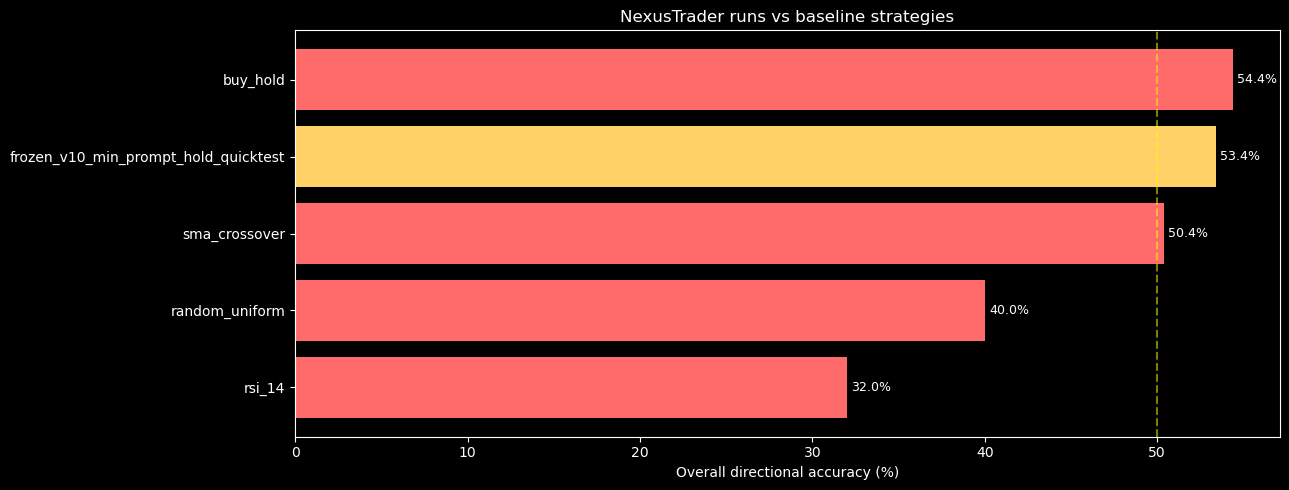

Saved chart: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\charts\clean_notebook_overall_accuracy.png
⚠ v6 not in current plot_df. This usually means old variables in kernel; rerun Cells 4, 8, 18, then this cell.


In [57]:
# Debug + plot to ensure the selected run tag is visible

# 1) Resolve expected tag from AGENT_RUN_GLOB (when a single file is selected)
expected_tag = None
if "*" not in AGENT_RUN_GLOB and AGENT_RUN_GLOB.endswith(".jsonl"):
    expected_tag, _ = parse_tag_and_timestamp(AGENT_RUN_GLOB)

print("AGENT_RUN_GLOB:", AGENT_RUN_GLOB)
print("Expected tag:", expected_tag)
print("\nAgent summary rows:")
display(agent_summary[["name", "n", "overall_acc", "buy_acc", "sell_acc", "hold_acc"]])

if expected_tag is not None and expected_tag not in set(agent_summary["name"]):
    print("⚠ Expected tag not found in agent_summary.")
    print("   Re-run Cells 4 → 8 → 18 (config, load runs, summary).")

# 2) Build plotting frame and sort for readability
plot_df = pd.concat([
    agent_summary.assign(group="agent")[["name", "overall_acc", "group"]],
    baseline_summary.assign(group="baseline")[["name", "overall_acc", "group"]],
], ignore_index=True)

plot_df = plot_df.dropna(subset=["overall_acc"]).sort_values("overall_acc", ascending=True).reset_index(drop=True)

# 3) Highlight expected run (if available)
def _color_for_row(row):
    if expected_tag is not None and row["name"] == expected_tag:
        return "#ffd166"  # highlight selected run
    return "#00d4aa" if row["group"] == "agent" else "#ff6b6b"

colors = plot_df.apply(_color_for_row, axis=1).tolist()

# 4) Plot
fig, ax = plt.subplots(figsize=(13, max(5, 0.55 * len(plot_df))))
ax.barh(plot_df["name"], plot_df["overall_acc"], color=colors)
ax.axvline(50, color="yellow", linestyle="--", alpha=0.5)
ax.set_xlabel("Overall directional accuracy (%)")
ax.set_title("NexusTrader runs vs baseline strategies")

for y, v in enumerate(plot_df["overall_acc"]):
    ax.text(v + 0.25, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
chart_path = CHART_DIR / "clean_notebook_overall_accuracy.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved chart:", chart_path)

# 5) Focused check for v6 visibility
if "frozen_v6_2debates" in set(plot_df["name"]):
    print("✅ v6 is present in plot_df.")
    display(plot_df[plot_df["name"] == "frozen_v6_2debates"])
else:
    print("⚠ v6 not in current plot_df. This usually means old variables in kernel; rerun Cells 4, 8, 18, then this cell.")

## 8b) Deep-Dive Diagnostic (Why Overall Is Low)

Selected tag: frozen_v10_min_prompt_hold_quicktest


,count,share_%,acc_%,contribution_to_overall_pp
action,,,,
BUY,22,18.64,68.18,12.71
SELL,46,38.98,58.70,22.88
HOLD,50,42.37,42.00,17.80


Overall accuracy = 53.39%
Sum of per-action weighted contributions = 53.39%

Confusion matrix (rows=true, cols=pred):


action,BUY,HOLD,SELL
true_label,,,
BUY,12,17,13
HOLD,3,21,12
SELL,7,12,21


Errors: 55/118 (46.6%)

Top directional misses by |k_return|:


,ticker,simulated_date,action,k_return,abs_return_%
83,NVDA,2023-05-15,SELL,0.385383,38.54
74,NVDA,2021-10-25,SELL,0.329707,32.97
85,NVDA,2023-10-30,SELL,0.181215,18.12
99,XOM,2021-12-27,SELL,0.106318,10.63
9,AAPL,2021-11-15,SELL,0.102000,10.20
69,JPM,2026-01-05,BUY,-0.089613,8.96
10,AAPL,2023-10-30,SELL,0.086637,8.66
3,AAPL,2025-02-24,BUY,-0.079401,7.94
44,JNJ,2026-01-26,SELL,0.077430,7.74
6,AAPL,2022-10-17,SELL,0.076750,7.67



Interpretation:
- BUY acc: 68.18% on n=22
- SELL acc: 58.70% on n=46
- HOLD acc: 42.00% on n=50 (42.4% of all calls)
- Overall is weighted by call counts; low HOLD accuracy drags the total down materially.

Gate check:
- SELL accuracy >= 45%: PASS
- HOLD share in [5%, 25%]: FAIL
- Overall >= 56% target: FAIL


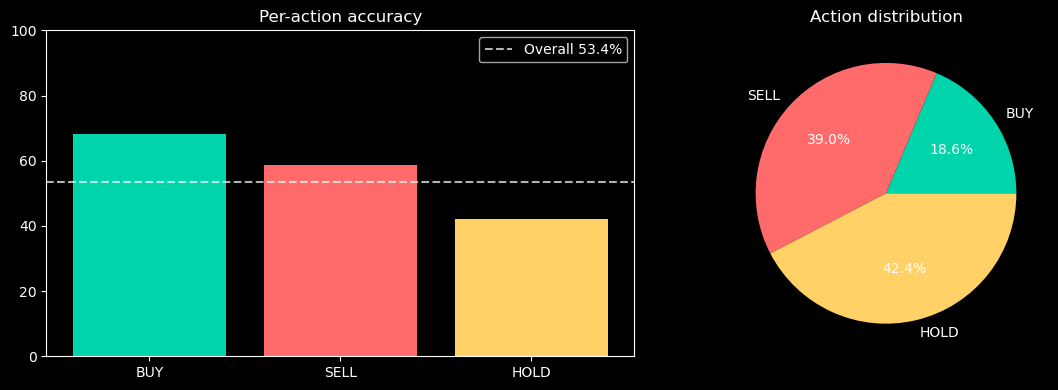

In [58]:
# Deep dive for selected run tag (defaults to the current AGENT_RUN_GLOB tag)

selected_tag = expected_tag if 'expected_tag' in globals() and expected_tag else 'frozen_v6_2debates'
print(f"Selected tag: {selected_tag}")

run_df = agent_df[agent_df['run_tag'] == selected_tag].copy()
if run_df.empty:
    raise ValueError(f"No rows found for run_tag={selected_tag}. Re-run Cells 4 and 8.")

# --- Core counts and weighted accuracy decomposition ---
counts = run_df['action'].value_counts().reindex(['BUY', 'SELL', 'HOLD']).fillna(0).astype(int)
acc_by_action = run_df.groupby('action')['correct'].mean().reindex(['BUY', 'SELL', 'HOLD'])
acc_by_action_pct = (acc_by_action * 100).round(2)

overall = run_df['correct'].mean() * 100
weighted_contrib = ((counts * acc_by_action.fillna(0)) / max(len(run_df), 1) * 100).round(2)

decomp = pd.DataFrame({
    'count': counts,
    'share_%': (counts / len(run_df) * 100).round(2),
    'acc_%': acc_by_action_pct,
    'contribution_to_overall_pp': weighted_contrib,
})

display(decomp)
print(f"Overall accuracy = {overall:.2f}%")
print(f"Sum of per-action weighted contributions = {decomp['contribution_to_overall_pp'].sum():.2f}%")

# --- Directional confusion matrix (true direction from k_return) ---
# True label definition aligned to scorer: BUY if ret>0, SELL if ret<0, HOLD if |ret|<epsilon
# Note: HOLD overlaps with BUY/SELL in strict sign space; for confusion view we assign HOLD first.
def true_label(ret, eps=HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    if abs(ret) < eps:
        return 'HOLD'
    return 'BUY' if ret > 0 else 'SELL'

run_df['true_label'] = run_df['k_return'].apply(true_label)
cm = pd.crosstab(run_df['true_label'], run_df['action'], dropna=False)
print("\nConfusion matrix (rows=true, cols=pred):")
display(cm)

# --- Error profile ---
errors = run_df[run_df['correct'] == 0].copy()
print(f"Errors: {len(errors)}/{len(run_df)} ({len(errors)/len(run_df)*100:.1f}%)")

if not errors.empty:
    # Large misses for directional calls
    dir_errors = errors[errors['action'].isin(['BUY', 'SELL'])].copy()
    if not dir_errors.empty:
        dir_errors['abs_return_%'] = (dir_errors['k_return'].abs() * 100).round(2)
        print("\nTop directional misses by |k_return|:")
        display(dir_errors[['ticker', 'simulated_date', 'action', 'k_return', 'abs_return_%']]
                .sort_values('abs_return_%', ascending=False)
                .head(15))

# --- Why 52% despite ~60% BUY/SELL ---
hold_share = counts.get('HOLD', 0) / len(run_df) * 100
hold_acc = acc_by_action_pct.get('HOLD', np.nan)
print("\nInterpretation:")
print(f"- BUY acc: {acc_by_action_pct.get('BUY', np.nan):.2f}% on n={counts.get('BUY', 0)}")
print(f"- SELL acc: {acc_by_action_pct.get('SELL', np.nan):.2f}% on n={counts.get('SELL', 0)}")
print(f"- HOLD acc: {hold_acc:.2f}% on n={counts.get('HOLD', 0)} ({hold_share:.1f}% of all calls)")
print("- Overall is weighted by call counts; low HOLD accuracy drags the total down materially.")

# --- Quick pass/fail gates ---
sell_gate = (acc_by_action_pct.get('SELL', 0) >= 45)
hold_rate_gate = (5 <= hold_share <= 25)
overall_gate = (overall >= 56.0)  # compare against v4-level target

print("\nGate check:")
print(f"- SELL accuracy >= 45%: {'PASS' if sell_gate else 'FAIL'}")
print(f"- HOLD share in [5%, 25%]: {'PASS' if hold_rate_gate else 'FAIL'}")
print(f"- Overall >= 56% target: {'PASS' if overall_gate else 'FAIL'}")

# --- Compact visual ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: action accuracy
axes[0].bar(['BUY', 'SELL', 'HOLD'], [acc_by_action_pct.get('BUY', 0), acc_by_action_pct.get('SELL', 0), acc_by_action_pct.get('HOLD', 0)], color=['#00d4aa', '#ff6b6b', '#ffd166'])
axes[0].axhline(overall, color='white', linestyle='--', alpha=0.7, label=f'Overall {overall:.1f}%')
axes[0].set_ylim(0, 100)
axes[0].set_title('Per-action accuracy')
axes[0].legend()

# Right: action mix
axes[1].pie([counts.get('BUY', 0), counts.get('SELL', 0), counts.get('HOLD', 0)], labels=['BUY', 'SELL', 'HOLD'], autopct='%1.1f%%', colors=['#00d4aa', '#ff6b6b', '#ffd166'])
axes[1].set_title('Action distribution')

plt.tight_layout()
plt.show()

## 8c) Return / PnL Deep-Dive (Not Just Accuracy)

This section computes realized strategy returns on the same scored runs:
- BUY → `k_return`
- SELL → `-k_return`
- HOLD → `0`

So we can evaluate whether prompt changes improved economic value, not only directional hit-rate.

Selected tag: frozen_v10_min_prompt_hold_quicktest
Scored rows used for return stats: 118

=== Return Summary ===
Mean strategy return per trade: 0.59%
Median strategy return per trade: 0.00%
Std dev of strategy return: 7.32%
Win rate (strategy_return > 0): 35.6%
Loss rate (strategy_return < 0): 22.0%
Flat rate (= 0, usually HOLD): 42.4%
Mean buy-and-hold return on same rows: 0.87%
Mean excess vs buy-and-hold: -0.28%

=== Returns by Action ===


,count,mean_%,median_%,std_%
action,,,,
BUY,22,2.423033,2.603164,6.697588
SELL,46,0.348024,1.218450,10.780704
HOLD,50,0.000000,0.000000,0.000000


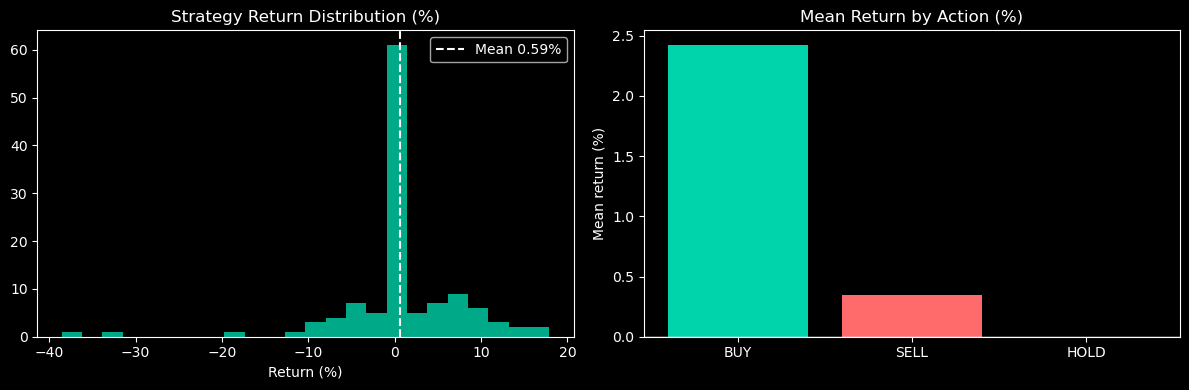

In [59]:
# Returns-based evaluation for selected run

ret_df = run_df.copy()
ret_df = ret_df.dropna(subset=['k_return']).copy()

# Strategy return per scored row
ret_df['strategy_return'] = np.where(
    ret_df['action'].eq('BUY'),
    ret_df['k_return'],
    np.where(ret_df['action'].eq('SELL'), -ret_df['k_return'], 0.0)
)
ret_df['buy_hold_return'] = ret_df['k_return']
ret_df['excess_vs_buy_hold'] = ret_df['strategy_return'] - ret_df['buy_hold_return']

# Core return stats
mean_ret = ret_df['strategy_return'].mean()
med_ret = ret_df['strategy_return'].median()
std_ret = ret_df['strategy_return'].std(ddof=1)
win_rate = (ret_df['strategy_return'] > 0).mean()
loss_rate = (ret_df['strategy_return'] < 0).mean()
flat_rate = (ret_df['strategy_return'] == 0).mean()

mean_bh = ret_df['buy_hold_return'].mean()
mean_excess = ret_df['excess_vs_buy_hold'].mean()

# Action-level return contribution
ret_by_action = (
    ret_df.groupby('action')['strategy_return']
    .agg(['count', 'mean', 'median', 'std'])
    .reindex(['BUY', 'SELL', 'HOLD'])
)

print(f"Selected tag: {selected_tag}")
print(f"Scored rows used for return stats: {len(ret_df)}")
print("\n=== Return Summary ===")
print(f"Mean strategy return per trade: {mean_ret*100:.2f}%")
print(f"Median strategy return per trade: {med_ret*100:.2f}%")
print(f"Std dev of strategy return: {std_ret*100:.2f}%")
print(f"Win rate (strategy_return > 0): {win_rate*100:.1f}%")
print(f"Loss rate (strategy_return < 0): {loss_rate*100:.1f}%")
print(f"Flat rate (= 0, usually HOLD): {flat_rate*100:.1f}%")
print(f"Mean buy-and-hold return on same rows: {mean_bh*100:.2f}%")
print(f"Mean excess vs buy-and-hold: {mean_excess*100:.2f}%")

print("\n=== Returns by Action ===")
display((ret_by_action * [1, 100, 100, 100]).rename(columns={'mean': 'mean_%', 'median': 'median_%', 'std': 'std_%'}))

# Compare against v4 benchmark if present
if 'frozen_v4_2debates' in set(agent_df['run_tag']):
    v4_df = agent_df[agent_df['run_tag'] == 'frozen_v4_2debates'].dropna(subset=['k_return']).copy()
    v4_df['strategy_return'] = np.where(
        v4_df['action'].eq('BUY'),
        v4_df['k_return'],
        np.where(v4_df['action'].eq('SELL'), -v4_df['k_return'], 0.0)
    )
    v4_mean = v4_df['strategy_return'].mean()
    print("\n=== v6 vs v4 Return Comparison (mean strategy return) ===")
    print(f"v6 ({selected_tag}): {mean_ret*100:.2f}%")
    print(f"v4 (frozen_v4_2debates): {v4_mean*100:.2f}%")
    print(f"Delta (v6 - v4): {(mean_ret - v4_mean)*100:.2f}%")

# Quick plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution plot
axes[0].hist(ret_df['strategy_return'] * 100, bins=24, color='#00d4aa', alpha=0.8)
axes[0].axvline(mean_ret * 100, color='white', linestyle='--', label=f"Mean {mean_ret*100:.2f}%")
axes[0].set_title('Strategy Return Distribution (%)')
axes[0].set_xlabel('Return (%)')
axes[0].legend()

# Action mean returns
means = ret_df.groupby('action')['strategy_return'].mean().reindex(['BUY', 'SELL', 'HOLD']).fillna(0) * 100
axes[1].bar(means.index, means.values, color=['#00d4aa', '#ff6b6b', '#ffd166'])
axes[1].axhline(0, color='white', linewidth=1)
axes[1].set_title('Mean Return by Action (%)')
axes[1].set_ylabel('Mean return (%)')

plt.tight_layout()
plt.show()

## 8d) Statistical Significance + Paired v4 vs v6 + HOLD Quality

In [60]:
# 1) Bootstrap CI for mean_excess (v6 vs buy&hold) ---------------------------------

def bootstrap_ci_mean(x, n_boot=10000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        sample = rng.choice(x, size=n, replace=True)
        means[i] = sample.mean()
    alpha = (100 - ci) / 2
    lo = np.percentile(means, alpha)
    hi = np.percentile(means, 100 - alpha)
    return x.mean(), lo, hi

v6_excess_mean, v6_excess_lo, v6_excess_hi = bootstrap_ci_mean(ret_df['excess_vs_buy_hold'], n_boot=10000, ci=95, seed=42)

print("=== Bootstrap significance: mean_excess (v6 - buy&hold) ===")
print(f"Point estimate: {v6_excess_mean*100:.3f}%")
print(f"95% CI: [{v6_excess_lo*100:.3f}%, {v6_excess_hi*100:.3f}%]")
if v6_excess_lo > 0:
    print("Result: CI excludes 0 on the positive side ✅ (reliable outperformance signal)")
elif v6_excess_hi < 0:
    print("Result: CI excludes 0 on the negative side ❌ (reliable underperformance signal)")
else:
    print("Result: CI crosses 0 ⚠ (improvement is not statistically reliable yet)")


# 2) Paired v4 vs v6 on same rows ------------------------------------------------------

v6_tag = selected_tag
v4_tag = 'frozen_v4_2debates'

if v4_tag not in set(agent_df['run_tag']):
    print(f"\n⚠ {v4_tag} not found in current agent_df. Include that file in AGENT_RUN_GLOB to run paired analysis.")
else:
    v6 = agent_df[agent_df['run_tag'] == v6_tag].copy()
    v4 = agent_df[agent_df['run_tag'] == v4_tag].copy()

    key_cols = ['ticker', 'simulated_date', 'horizon']
    keep_cols = key_cols + ['action', 'k_return', 'correct']

    v6 = v6[keep_cols].rename(columns={
        'action': 'action_v6',
        'k_return': 'k_return_v6',
        'correct': 'correct_v6'
    })
    v4 = v4[keep_cols].rename(columns={
        'action': 'action_v4',
        'k_return': 'k_return_v4',
        'correct': 'correct_v4'
    })

    paired = v6.merge(v4, on=key_cols, how='inner')
    print(f"\n=== Paired overlap ({v6_tag} vs {v4_tag}) ===")
    print(f"Rows in v6: {len(v6)} | Rows in v4: {len(v4)} | Overlap: {len(paired)}")

    if len(paired) == 0:
        print("⚠ No overlapping rows. Ensure both runs were created from the same universe.")
    else:
        # Use one return column for paired rows (should be same market horizon outcome)
        paired['k_return'] = paired['k_return_v6'].fillna(paired['k_return_v4'])

        def strat_ret(action, kret):
            if pd.isna(kret):
                return np.nan
            if action == 'BUY':
                return kret
            if action == 'SELL':
                return -kret
            return 0.0

        paired['ret_v6'] = [strat_ret(a, r) for a, r in zip(paired['action_v6'], paired['k_return'])]
        paired['ret_v4'] = [strat_ret(a, r) for a, r in zip(paired['action_v4'], paired['k_return'])]
        paired['excess_v6'] = paired['ret_v6'] - paired['k_return']
        paired['excess_v4'] = paired['ret_v4'] - paired['k_return']

        overall_acc_v6 = paired['correct_v6'].mean() * 100
        overall_acc_v4 = paired['correct_v4'].mean() * 100

        sell_mask_v6 = paired['action_v6'].eq('SELL')
        sell_mask_v4 = paired['action_v4'].eq('SELL')
        hold_mask_v6 = paired['action_v6'].eq('HOLD')
        hold_mask_v4 = paired['action_v4'].eq('HOLD')

        sell_acc_v6 = paired.loc[sell_mask_v6, 'correct_v6'].mean() * 100 if sell_mask_v6.any() else np.nan
        sell_acc_v4 = paired.loc[sell_mask_v4, 'correct_v4'].mean() * 100 if sell_mask_v4.any() else np.nan
        hold_acc_v6 = paired.loc[hold_mask_v6, 'correct_v6'].mean() * 100 if hold_mask_v6.any() else np.nan
        hold_acc_v4 = paired.loc[hold_mask_v4, 'correct_v4'].mean() * 100 if hold_mask_v4.any() else np.nan

        mean_ret_v6 = paired['ret_v6'].mean() * 100
        mean_ret_v4 = paired['ret_v4'].mean() * 100
        mean_excess_v6 = paired['excess_v6'].mean() * 100
        mean_excess_v4 = paired['excess_v4'].mean() * 100

        cmp = pd.DataFrame([
            ['overall_acc', overall_acc_v6, overall_acc_v4, overall_acc_v6 - overall_acc_v4],
            ['sell_acc', sell_acc_v6, sell_acc_v4, sell_acc_v6 - sell_acc_v4],
            ['hold_acc', hold_acc_v6, hold_acc_v4, hold_acc_v6 - hold_acc_v4],
            ['mean_strategy_return_%', mean_ret_v6, mean_ret_v4, mean_ret_v6 - mean_ret_v4],
            ['mean_excess_vs_bh_%', mean_excess_v6, mean_excess_v4, mean_excess_v6 - mean_excess_v4],
        ], columns=['metric', 'v6', 'v4', 'delta_v6_minus_v4'])

        print("\n=== Paired metric deltas (v6 - v4) ===")
        display(cmp)


# 3) HOLD quality diagnostics -----------------------------------------------------------

hold_df = run_df[run_df['action'].eq('HOLD')].copy()
if hold_df.empty:
    print("\n=== HOLD quality ===")
    print("No HOLD predictions in selected run.")
else:
    hold_df['abs_k_return'] = hold_df['k_return'].abs()
    hold_within_band = (hold_df['abs_k_return'] < HOLD_EPSILON).mean() * 100
    hold_far_misses = (hold_df['abs_k_return'] >= HOLD_EPSILON).sum()

    print("\n=== HOLD quality ===")
    print(f"HOLD count: {len(hold_df)}")
    print(f"HOLD correct-rate (already shown): {hold_df['correct'].mean()*100:.2f}%")
    print(f"Fraction of HOLDs truly within neutral band (|k_return|<{HOLD_EPSILON:.3f}): {hold_within_band:.2f}%")
    print(f"HOLD far misses (|k_return|>=epsilon): {hold_far_misses}")

    print("Top HOLD misses by |k_return| (these should likely be directional calls):")
    display(
        hold_df[hold_df['abs_k_return'] >= HOLD_EPSILON][['ticker', 'simulated_date', 'horizon', 'k_return', 'abs_k_return']]
        .sort_values('abs_k_return', ascending=False)
        .head(15)
    )

print("\nActionable prompt tweak for HOLD:")
print("- In Trader and Risk Manager prompts, add: 'Use HOLD only when evidence is genuinely mixed AND expected move is likely inside ±2.5% over horizon; otherwise commit to BUY/SELL.'")

=== Bootstrap significance: mean_excess (v6 - buy&hold) ===
Point estimate: -0.282%
95% CI: [-2.895%, 2.037%]
Result: CI crosses 0 ⚠ (improvement is not statistically reliable yet)

⚠ frozen_v4_2debates not found in current agent_df. Include that file in AGENT_RUN_GLOB to run paired analysis.

=== HOLD quality ===
HOLD count: 50
HOLD correct-rate (already shown): 42.00%
Fraction of HOLDs truly within neutral band (|k_return|<0.025): 42.00%
HOLD far misses (|k_return|>=epsilon): 29
Top HOLD misses by |k_return| (these should likely be directional calls):


,ticker,simulated_date,horizon,k_return,abs_k_return
91,NVDA,2023-01-09,short,0.232723,0.232723
103,XOM,2022-01-17,short,0.106048,0.106048
108,XOM,2022-10-17,short,0.101272,0.101272
77,NVDA,2021-11-15,short,0.088293,0.088293
112,XOM,2022-08-15,short,0.084489,0.084489
49,JNJ,2025-09-22,short,0.080076,0.080076
115,XOM,2024-12-02,short,-0.079593,0.079593
66,JPM,2024-06-17,short,0.071033,0.071033
107,XOM,2021-11-15,short,-0.070374,0.070374
20,AAPL,2022-08-15,short,-0.068191,0.068191



Actionable prompt tweak for HOLD:
- In Trader and Risk Manager prompts, add: 'Use HOLD only when evidence is genuinely mixed AND expected move is likely inside ±2.5% over horizon; otherwise commit to BUY/SELL.'


## 9) Optional: One-Click Export Bundle

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

agent_summary_out = SCORED_DIR / f"summary_agent_runs_{timestamp}.csv"
baseline_summary_out = SCORED_DIR / f"summary_baselines_{timestamp}.csv"
combined_summary_out = SCORED_DIR / f"summary_combined_{timestamp}.csv"

combined_summary = pd.concat([
    agent_summary.assign(type="agent"),
    baseline_summary.assign(type="baseline"),
], ignore_index=True)

agent_summary.to_csv(agent_summary_out, index=False)
baseline_summary.to_csv(baseline_summary_out, index=False)
combined_summary.to_csv(combined_summary_out, index=False)

print("Saved:", agent_summary_out)
print("Saved:", baseline_summary_out)
print("Saved:", combined_summary_out)

## 10) Repro Steps

Run cells top-to-bottom.

Artifacts created:
- `results/scored/agent_runs_scored_registry.csv`
- `results/scored/baselines_registry.csv`
- `results/scored/summary_*.csv`
- `results/charts/clean_notebook_overall_accuracy.png`

This notebook is now your stable analysis workflow for v3/v4/v5 + baselines.